In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch as tch
import torch.nn as nn

tch.cuda.is_available()


True

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_bank = pd.read_csv('bank.csv')
data_bank["default"]=data_bank["default"].map({"no":0,"yes":1})
data_bank["housing"]=data_bank["housing"].map({"no":0,"yes":1})
data_bank["loan"]=data_bank["loan"].map({"no":0,"yes":1})
data_bank["deposit"]=data_bank["deposit"].map({"no":0,"yes":1})
edu_map = {"unknown":0,
           "primary":1,
           "secondary":2,
           "tertiary":3}
data_bank["education"]=data_bank["education"].map(edu_map)
data_bank = pd.get_dummies(data_bank, columns=['education'], dtype=int)
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# 1. Переводим строки в числа 1-12
data_bank['month_num'] = data_bank['month'].map(month_map)

# 2. Создаем циклические признаки
# 2 * pi / 12 — это полный круг (12 месяцев)
data_bank['month_sin'] = np.sin(2 * np.pi * data_bank['month_num'] / 12)
data_bank['month_cos'] = np.cos(2 * np.pi * data_bank['month_num'] / 12)

# Теперь можно удалить исходную колонку и промежуточную month_num
data_bank = data_bank.drop(['month', 'month_num'], axis=1)
data_bank = pd.get_dummies(data_bank, columns=['poutcome'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['contact'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['marital'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['job'], dtype=int)

y = data_bank['deposit']
X = data_bank.drop('deposit', axis=1)

X_train, X_test, y_bank_train, y_bank_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_bank_train = scaler.fit_transform(X_train)
X_bank_test = scaler.transform(X_test)


In [40]:
# Тензоры
X_bank_train_tensor = tch.FloatTensor(X_bank_train)
y_bank_train_tensor = tch.FloatTensor(y_bank_train.values).reshape(-1, 1)
X_bank_test_tensor = tch.FloatTensor(X_bank_test)
y_bank_test_tensor = tch.FloatTensor(y_bank_test.values).reshape(-1, 1)

# DataLoader
bank_train_dataset = tch.utils.data.TensorDataset(X_bank_train_tensor, y_bank_train_tensor)
bank_train_loader = tch.utils.data.DataLoader(bank_train_dataset, batch_size=64, shuffle=True)

In [41]:
class MLPClassifier_for_bank(nn.Module):
    def __init__(self, input_size, hidden_sizes=[32, 16, 8], dropout_rate=0.3):
        super(MLPClassifier_for_bank, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1)) # 1 это зависит от классов сколько вариантов ответов  столько и ставиться 
        layers.append(nn.Sigmoid())

        self.networks = nn.Sequential(*layers)

    def forward(self, x):
        return self.networks(x)
    

In [42]:
import torch.optim as optim

# 1. Создаём модель
model_bank = MLPClassifier_for_bank(input_size=X_bank_train.shape[1])

# 2. Функция потерь (как модель понимает, что ошиблась)
criterion = nn.BCELoss()

# 3. Оптимизатор (как модель исправляет ошибки)
optimizer = optim.Adam(model_bank.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

print("Модель готова к обучению!")
print(model_bank)

Модель готова к обучению!
MLPClassifier_for_bank(
  (networks): Sequential(
    (0): Linear(in_features=38, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=8, bias=True)
    (9): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=8, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


In [43]:
train_losses = []
model_bank.train()
num_epochs = 30

In [44]:
best_loss = float('inf')
patience = 5
no_improve = 0

for epoch in range(num_epochs):
        epoch_loss = 0
        correct = 0
        total = 0
        # if avg_loss < best_loss - 0.001:  # Улучшение есть
        #     best_loss = avg_loss
        #     no_improve = 0
        # else:
        #     no_improve += 1
        
        # if no_improve >= patience:
        #     print(f"🛑 Early Stop на эпохе {epoch+1}")
        #     break
        
        for batch_X, batch_y in bank_train_loader:
        # ─────────────────────────────────────
        # 1. Обнуляем старые градиенты
        # ─────────────────────────────────────    
            optimizer.zero_grad()
        # ─────────────────────────────────────
        # 2. FORWARD (Прямой проход)
        # ─────────────────────────────────────
            outputs = model_bank(batch_X)
        # ─────────────────────────────────────
        # 2. Считаем ошибку (Loss)
        # ─────────────────────────────────────
            loss = criterion(outputs, batch_y)
        # ─────────────────────────────────────
        # 4. BACKWARD (Обратный проход) ⚠️
        # ─────────────────────────────────────
            loss.backward()
        # ─────────────────────────────────────
        # 5. STEP (Исправляем веса)
        # ─────────────────────────────────────
            optimizer.step()
        # ─────────────────────────────────────
        # 6. Считаем метрики для отчёта
        # ─────────────────────────────────────
            
            epoch_loss += loss.item()
            
            # ✅ Добавил подсчёт точности
            predicted_classes = (outputs >= 0.5).float()
            correct += (predicted_classes == batch_y).sum().item()
            total += batch_y.size(0)

        scheduler.step()
        avg_loss = epoch_loss / len(bank_train_loader)
        accuracy = correct / total
        train_losses.append(avg_loss)

        # ✅ Выводим и Loss, и Accuracy
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}: Loss = {avg_loss:.4f} | Accuracy = {accuracy:.4f}')


Epoch 10: Loss = 0.4311 | Accuracy = 0.8112
Epoch 20: Loss = 0.4107 | Accuracy = 0.8270
Epoch 30: Loss = 0.4007 | Accuracy = 0.8317


In [46]:
from sklearn.metrics import accuracy_score, roc_auc_score

# === 1. Оценка на тренировочных данных ===
model_bank.eval()
with tch.no_grad():
    # Train
    train_pred = model_bank(X_bank_train_tensor)
    train_proba = train_pred.numpy().flatten()
    train_classes = (train_pred >= 0.5).float().numpy().flatten()
    
    train_acc = accuracy_score(y_bank_train, train_classes)
    train_auc = roc_auc_score(y_bank_train, train_proba)
    
    # Test
    test_pred = model_bank(X_bank_test_tensor)
    test_proba = test_pred.numpy().flatten()
    test_classes = (test_pred >= 0.5).float().numpy().flatten()
    
    test_acc = accuracy_score(y_bank_test, test_classes)
    test_auc = roc_auc_score(y_bank_test, test_proba)

# === 2. Печатаем сравнение ===
print("📊 Сравнение метрик:")
print(f"{'Метрика':<12} {'Train':>10} {'Test':>10} {'Разница':>10}")
print("-" * 45)
print(f"{'Accuracy':<12} {train_acc:>10.4f} {test_acc:>10.4f} {abs(train_acc-test_acc):>10.4f}")
print(f"{'ROC-AUC':<12} {train_auc:>10.4f} {test_auc:>10.4f} {abs(train_auc-test_auc):>10.4f}")

    #Тестовая точность: 0.8515
#64, 32, 16
# 📊 Сравнение метрик:
# Метрика           Train       Test    Разница
# ---------------------------------------------
# Accuracy         0.8642     0.8515     0.0126
# ROC-AUC          0.9245     0.9072     0.0173

#4 слоя 128 64 32 16
# 📊 Сравнение метрик:
# Метрика           Train       Test    Разница
# ---------------------------------------------
# Accuracy         0.8640     0.8517     0.0123
# ROC-AUC          0.9246     0.9065     0.0181


📊 Сравнение метрик:
Метрика           Train       Test    Разница
---------------------------------------------
Accuracy         0.8522     0.8316     0.0206
ROC-AUC          0.9211     0.9094     0.0117


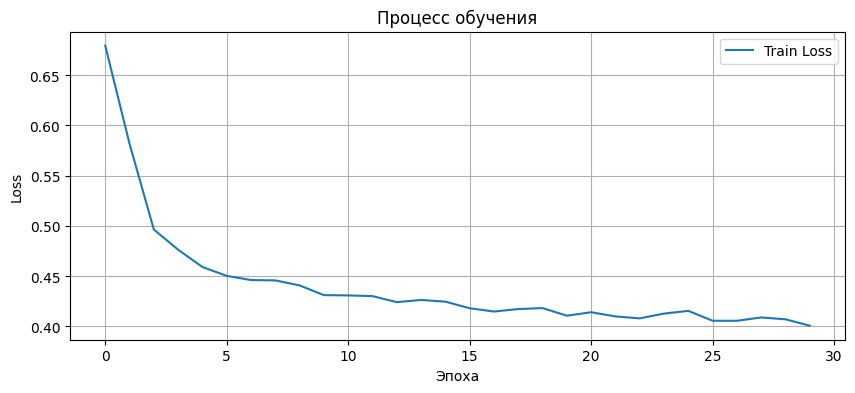

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Процесс обучения')
plt.grid(True)
plt.legend()
plt.show()

In [48]:
print(model_bank)

MLPClassifier_for_bank(
  (networks): Sequential(
    (0): Linear(in_features=38, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=8, bias=True)
    (9): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=8, out_features=1, bias=True)
    (13): Sigmoid()
  )
)



📊 МЕТРИКИ НА ТЕСТЕ:
------------------------------
Accuracy       : 0.8316
Precision      : 0.8028
Recall         : 0.8544
F1-Score       : 0.8278
ROC-AUC        : 0.9094
PR-AUC (AP)    : 0.8792
------------------------------


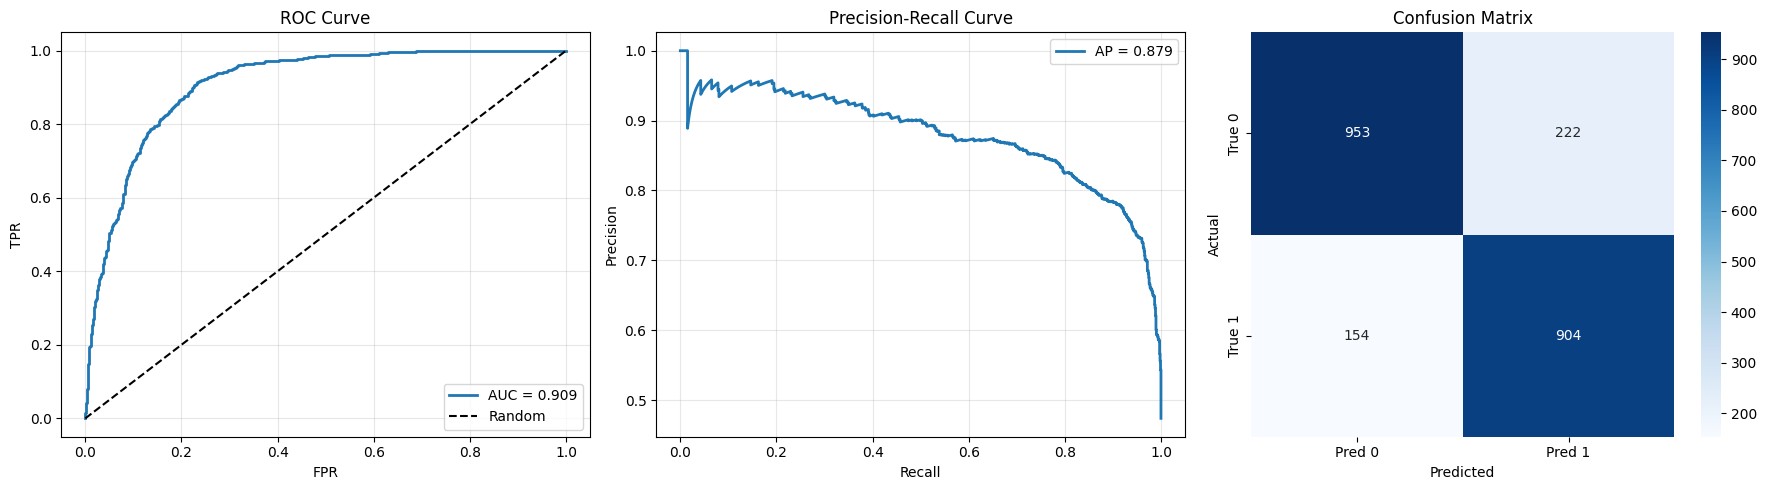

In [49]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, f1_score, average_precision_score,
                             roc_curve, precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем все метрики
metrics = {
    'Accuracy': accuracy_score(y_bank_test, test_classes),
    'Precision': precision_score(y_bank_test, test_classes),
    'Recall': recall_score(y_bank_test, test_classes),
    'F1-Score': f1_score(y_bank_test, test_classes),
    'ROC-AUC': roc_auc_score(y_bank_test, test_proba),
    'PR-AUC (AP)': average_precision_score(y_bank_test, test_proba)
}

# 2. Вывод метрик
print("\n📊 МЕТРИКИ НА ТЕСТЕ:")
print("-" * 30)
for name, value in metrics.items():
    print(f"{name:15s}: {value:.4f}")
print("-" * 30)

# 3. Графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: ROC Curve
fpr, tpr, _ = roc_curve(y_bank_test, test_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {metrics['ROC-AUC']:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# График 2: PR Curve
precisions, recalls, _ = precision_recall_curve(y_bank_test, test_proba)
axes[1].plot(recalls, precisions, label=f"AP = {metrics['PR-AUC (AP)']:.3f}", linewidth=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

# График 3: Confusion Matrix
cm = confusion_matrix(y_bank_test, test_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# # 4. БОНУС: Оптимальный порог по F1
# prec_pr, rec_pr, thresh_pr = precision_recall_curve(y_bank_test, test_proba)
# f1_scores = 2 * (prec_pr[:-1] * rec_pr[:-1]) / (prec_pr[:-1] + rec_pr[:-1] + 1e-8)
# best_idx = f1_scores.argmax()
# print(f"\n⚡ Оптимальный порог: {thresh_pr[best_idx]:.3f} → F1 = {f1_scores[best_idx]:.4f}")